In [263]:
# %pip install torch_geometric
# %pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.4.0+cu121.html

In [264]:
import DeviceDir

DIR, RESULTS_DIR = DeviceDir.get_directory()
device, NUM_PROCESSORS = DeviceDir.get_device()

In [265]:
import os
import torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid, Reddit
from torch_geometric.nn import GCNConv
from torch_geometric.loader import ClusterData, ClusterLoader
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt
import time
from torch_geometric.datasets import WikipediaNetwork
from sklearn.model_selection import train_test_split
from torch_geometric.typing import Adj, SparseTensor
from ogb.nodeproppred import Evaluator, PygNodePropPredDataset
from torch_geometric.utils import scatter
from torch_geometric.datasets import Reddit, Reddit2, Flickr, Yelp, AmazonProducts, PPI,  OGB_MAG,  FakeDataset, Amazon,Coauthor,HeterophilousGraphDataset, CitationFull
from torch_geometric.utils import homophily
from torch_geometric.utils import negative_sampling
from torch_geometric.utils import add_random_edge

def fix_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fix_seeds()

In [266]:
# from torch_geometric.datasets import LINKXDataset
# dataset_name = 'Roman-empire'
# dataset = HeterophilousGraphDataset('/tmp/Cora', DATASET_NAME)
# DATASET_NAME = dataset_name
# data = dataset[0]
# print(data)

In [267]:
from torch_geometric.datasets import KarateClub, Reddit, Reddit2, Flickr, Yelp, AmazonProducts, PPI,  OGB_MAG,  FakeDataset, Amazon,Coauthor,HeterophilousGraphDataset,LINKXDataset

def load_dataset(dataset_name):
    if dataset_name == "karate":
        dataset = KarateClub()
    elif dataset_name == "moon":
        from ipynb.fs.full.Moon import MoonDataset
        dataset = MoonDataset(n_samples=1000, degree=4, train=0.2, h = 0.2)
    elif dataset_name == "SmallCora":
        dataset = Planetoid(root=DIR+'/tmp/Cora', name='Cora')
    elif dataset_name in ["Cora", "Cora_ML", "CiteSeer", "DBLP", "PubMed"]:
        dataset = CitationFull(root=DIR+'/tmp/Citation/'+dataset_name, name=dataset_name)
    elif dataset_name == 'Amazon-ratings':
        dataset = HeterophilousGraphDataset(root=DIR+'/tmp/amazon_ratings', name = dataset_name)
    elif dataset_name == 'Roman-empire':
        from torch_geometric.datasets import LINKXDataset
        dataset = LINKXDataset(DIR+'/tmp/Roman_empire', dataset_name)
    elif dataset_name == "Reddit":
        dataset = Reddit(root=DIR+'/tmp/Reddit')
    elif dataset_name == 'penn94':
        from torch_geometric.datasets import LINKXDataset
        dataset = LINKXDataset(root=DIR+'/tmp/LINKX', name=dataset_name)
    elif dataset_name == 'wiki':
        from torch_geometric.datasets import WikiCS
        dataset = WikiCS(root=DIR+'/tmp/WikiCS')
    elif dataset_name == 'Photo':
        dataset = Amazon(root=DIR+'/tmp/Photo', name='Photo')
    elif dataset_name == 'CiteSeer':
        dataset = Planetoid(root=DIR+'/tmp/CiteSeer', name=DATASET_NAME)
    elif dataset_name == 'CS':
        dataset = Coauthor(root=DIR+'/tmp/CS', name = DATASET_NAME)
    elif dataset_name == 'Physics':
        dataset = Coauthor(root=DIR+'/tmp/Physics', name = DATASET_NAME)
    elif dataset_name == 'Minesweeper':
        dataset   = HeterophilousGraphDataset(root=DIR+'/tmp/Mine',name=dataset_name)
    elif dataset_name == 'pokec':
        print("HELLOWROLD ")
    elif dataset_name == 'ogbn-proteins':
        dataset = PygNodePropPredDataset(name='ogbn-proteins', root=DIR+'/tmp/ogbn-proteins')
        data = dataset[0]
        data.node_species = None
        data.y = data.y.to(torch.float)

        # Initialize features of nodes by aggregating edge features.
        row, col = data.edge_index
        data.x = scatter(data.edge_attr, col, dim_size=data.num_nodes, reduce='sum')
        labels = data.y.argmax(dim=1)
        data.y = labels
        return dataset, data
    elif dataset_name == 'squirrel':
        dataset = WikipediaNetwork(root=DIR+'/tmp/squirrel', name='Squirrel')
    elif dataset_name == 'AmazonProducts':
        dataset = AmazonProducts(root=DIR+'/tmp/AmazonProducts')
    else:
        #dataset = Planetoid(root=DIR+'/tmp/Cora', name='Cora')
        raise NotImplementedError

    print(dataset)
    data = dataset[0]
    print(data)
    return dataset, data

# Example usage
dataset_name = "SmallCora"
DATASET_NAME = dataset_name
dataset, data = load_dataset(dataset_name)

Cora()
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [268]:
# dataset_name = 'Roman-empire'
# DATASET_NAME = dataset_name
# dataset   = HeterophilousGraphDataset(root='/tmp/roman',name=dataset_name)
# print(data)

In [269]:
dataset.num_classes
He = homophily(data.edge_index, data.y, method='edge')
print("Edge Homophily: ", He)

Edge Homophily:  0.8099659085273743


In [270]:
def train_val_test_mask(data, train=0.4, val=0.3, test=0.3, random_state=False):

    if isinstance(data.x, SparseTensor):
        N = data.x.size(0)
        data.num_nodes = N
    else:
        N = data.x.shape[0]

    indexs = list(range(N))

    if random_state:
        train_index, test_index = train_test_split(indexs, test_size=val+test)
        val_index, test_index = train_test_split(test_index, test_size=test/(val+test))
    else:
        train_index, test_index = train_test_split(indexs, test_size=val+test, random_state=1)
        val_index, test_index = train_test_split(test_index, test_size=test/(val+test), random_state=1)



    train_mask = torch.zeros(N, dtype=bool)
    train_mask[train_index]=True
    val_mask = torch.zeros(N, dtype=bool)
    val_mask[val_index]=True
    test_mask = torch.zeros(N, dtype=bool)
    test_mask[test_index]=True

    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask

    return data

In [271]:
if "val_mask" not in data.__dict__['_store']:    
    data = train_val_test_mask(data, train=0.2, val=0.4, test=0.4)

if len(data.train_mask.shape) > 1:
    split_index = 2
    data.train_mask = data.train_mask[:,split_index]
    data.val_mask = data.val_mask[:,split_index]
    data.test_mask = data.test_mask[:,split_index]

In [272]:
# Define the MLP for edge probability with dropout
class EdgeProbMLP(nn.Module):
    def __init__(self, in_channels, hidden_dim, dropout_prob=0.2):
        super(EdgeProbMLP, self).__init__()
        self.gcn1 = GCNConv(in_channels, hidden_dim)
        self.dropout = nn.Dropout(dropout_prob)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)
        self.fc1 = nn.Linear(2 * hidden_dim, hidden_dim)
        # self.fc_residual = nn.Linear(2 * hidden_dim, hidden_dim)  # For residual connection
        #self.fc1 = nn.Linear(2 * in_channels, hidden_dim) #if straightforward link
        self.dropout = nn.Dropout(dropout_prob)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, node_features, edge_index):

        #x = node_features[edge_index[0]]
        #y = node_features[edge_index[1]]
        
        out = F.relu(self.gcn1(node_features, edge_index))
        out = self.dropout(out)
        out = self.gcn2(out, edge_index)
        
        x = out[edge_index[0]]
        y = out[edge_index[1]]
        
        edge_features = torch.cat([x*y,x-y], dim=1) #x*y|x-y
        x = F.relu(self.fc1(edge_features))
        # x = x + self.fc_residual(edge_features) #  # Add residual connection
        x = self.dropout(x)
        prob = torch.sigmoid(self.fc2(x))
        # prob.requires_grad_(True)
        return prob
# class EdgeProbMLP(nn.Module):
#     def __init__(self, in_channels, hidden_dim):
#         super(EdgeProbMLP, self).__init__()
#         self.fc1 = nn.Linear(2 * in_channels, hidden_dim)
#         self.fc2 = nn.Linear(hidden_dim, 1)

#     def forward(self, node_features, edge_index):
#         edge_features = torch.cat([node_features[edge_index[0]], node_features[edge_index[1]]], dim=1)
#         x = F.relu(self.fc1(edge_features))
#         prob = torch.sigmoid(self.fc2(x))
#         #prob = F.softmax(self.fc2(x),dim=0)
#         #prob = F.relu(self.fc2(x))
#         return prob
    
#     def reset_parameters(self):
#         self.fc1.reset_parameters()
#         self.fc2.reset_parameters()

# Define the overall model with Edge Probabilities and GCNConv (GNN) with dropout
class GNNModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_channels, num_classes, dropout_prob=0.3):
        super(GNNModel, self).__init__()
        self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim, dropout_prob)
        # self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim)
        self.gcn1 = GCNConv(in_channels, hidden_dim)
        self.dropout = nn.Dropout(dropout_prob)
        self.gcn2 = GCNConv(hidden_dim, num_classes)

    def forward(self, data, edge_index, edge_weight=None):
        x = F.relu(self.gcn1(data.x, edge_index, edge_weight))
        x = self.dropout(x)
        out = self.gcn2(x, edge_index, edge_weight)
        return out

In [273]:
def plot_probs(edge_probs,sampling_probs):
    ep = edge_probs.detach().cpu().numpy()
    sp = sampling_probs.detach().cpu().numpy()
    
    plt.figure(figsize=(20, 6))    
    plt.subplot(2, 1, 1)

    #plt.plot(ep)
    plt.scatter(range(len(ep)), ep, s=2)
    plt.title('Curve of Edge Probs')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.grid(True)

    plt.subplot(2, 1, 2)
    #plt.plot(sp)
    plt.scatter(range(len(sp)), sp, s=2)
    plt.title('Curve of Samples Probs')
    plt.xlabel('Index')
    plt.ylabel('Probability')
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
    
def plot_hist(edge_probs,sampling_probs, ep_select, sp_select):
    ep = edge_probs.detach().cpu().numpy()
    sp = sampling_probs.detach().cpu().numpy()
    ep_select = ep_select.detach().cpu().numpy()
    sp_select = sp_select.detach().cpu().numpy()
    
    plt.figure(figsize=(20, 15))    
    plt.subplot(4, 1, 1)

    #plt.plot(ep)
    plt.hist(ep, bins= 30, edgecolor='black')
    plt.title('Histogram of Edge Probs')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.grid(True)

    plt.subplot(4, 1, 2)
    #plt.plot(sp)
    plt.hist(sp, bins= 30, edgecolor='black')
    plt.title('histogram of Samples Probs')
    plt.xlabel('Index')
    plt.ylabel('Probability')
    plt.grid(True)

    plt.subplot(4, 1, 3)
    #plt.plot(sp)
    plt.hist(ep_select, bins= 30, edgecolor='black')
    plt.title('histogram of selected Edge Probs')
    plt.xlabel('Index')
    plt.ylabel('Probability')
    plt.grid(True)
    
    plt.subplot(4, 1, 4)
    #plt.plot(sp)
    plt.hist(sp_select, bins= 30, edgecolor='black')
    plt.title('histogram of selected sampled Probs')
    plt.xlabel('Index')
    plt.ylabel('Probability')
    plt.grid(True)

    
    
    plt.tight_layout()
    plt.show()
    

In [274]:
from torch_geometric.utils import to_scipy_sparse_matrix
import scipy.sparse as sp

In [275]:
# Gumbel-Softmax trick for edge sampling
def gumbel_softmax_sampling(batch, edge_probs, edge_index, q=500, temperature=1.0, log=False, istest=False, epoch=-1):
        
    if istest:
        # samples = torch.exp(edge_probs)/torch.exp(edge_probs).sum()
        samples = edge_probs/edge_probs.sum()
        samples = 0.7 * samples + 0.3*data.prob #temporary
        # samples = F.softmax(edge_probs/temperature, dim=-1)
        #top_k_values, sampled_edges = torch.topk(edge_probs, q, dim=-1, largest=True, sorted=True)
        sampled_edges = torch.multinomial(samples, q, replacement=False) #nothing
        # edge_gradients = edge_probs.grad
        # sampled_edges = torch.topk(edge_gradients.abs(),k=q)
    else:
        # warmup_epochs = 20  # Number of epochs for the warm-up phase
        # if epoch< warmup_epochs:
            # samples = F.softmax(batch.prob, dim=-1)
            # sampled_edges = torch.multinomial(samples, q, replacement=False) #nothing               
        # else:
        # samples = torch.exp(edge_probs)/torch.exp(edge_probs).sum()
        # edge_probs += torch.ones_like(edge_probs)/len(edge_probs)
        samples =  edge_probs/edge_probs.sum()
        # samples = F.softmax(edge_probs/temperature, dim=-1)
        # samples = 0.1*samples + 0.9*torch.rand_like(samples)
        samples = 0.7 * samples + 0.3*data.prob
        sampled_edges = torch.multinomial(samples, q, replacement=False) #nothing
#         gumbels = -torch.empty_like(edge_probs).exponential_().log()
#         gumbels = (gumbels - gumbels.min()) / (gumbels.max() - gumbels.min())
        
#         #noise = 1.0 + (epoch/100)*9.0
#         noise = 1.0
        
#         gumbels = gumbels/noise
        
    
# #         gumbels = 0

#         logits = (edge_probs + gumbels) / temperature    
#         samples = F.softmax(logits, dim=-1)

        #top_k_values, sampled_edges = torch.topk(samples, q, dim=-1, largest=True, sorted=True) # 50       
        
    
        #print(f'{torch.mean(samples).item():.4f}, {torch.var(samples).item():.4f}, {torch.std(samples).item():.4f}')    
        #print("EP: ",torch.mean(edge_probs).item(), torch.var(edge_probs).item())
        #print("SP: ",torch.mean(samples).item(), torch.var(samples).item())
    
    # if epoch%10 == 0:
    
#     print("Test" if istest == True else "Train")
#     print(edge_probs)
#     print(samples)   
        #plot_probs(edge_probs, samples)
#         plot_hist(edge_probs, samples, edge_probs[sampled_edges],samples[sampled_edges])
    
#     adj = to_scipy_sparse_matrix(data.edge_index[:,sampled_edges], num_nodes=data.num_nodes)
#     num_components, component = sp.csgraph.connected_components(adj, connection='weak')
#     print("Components: ", num_components)
    
#     sampled_edges = torch.multinomial(samples, q, replacement=False)
#     top_k_values, sampled_edges = torch.topk(edge_probs, q, dim=-1, largest=True, sorted=True)    

    
    one_hot = torch.zeros_like(samples)
    one_hot.scatter_(0, sampled_edges, 1.0)     
    
    indexs = (one_hot - samples).detach() + samples
    
    edge_probs = edge_probs*indexs
    indexs = indexs.bool()
    
    
#     if log:        
#         print("edge_probs: ",edge_probs)
# #         print("gumbels: ", gumbels)
# #         print("logits: ",logits)
#         print("samples: ",samples)
#         print("sampled_edges: ",sampled_edges)
#         print("One hot: ", one_hot)
#         print("Indexs: ",indexs)
#         print("edge_probs[indexs]:", edge_probs[indexs])

    
#     return indexs, edge_probs[indexs]
    
    return indexs, edge_probs[indexs]+0.01
    #return indexs, torch.clamp(edge_probs[indexs]+10, max=1.0)


# Random edge sampling
def random_edge_sampling(edge_index, q):
    num_edges = edge_index.shape[1]
    sampled_indices = torch.randperm(num_edges)[:q]
    sampled_edge_index = edge_index[:, sampled_indices]
    return sampled_edge_index

# F1 score calculation helper
def calculate_f1(logits, labels, mask):
    preds = logits[mask].argmax(dim=1)
    f1 = f1_score(labels[mask].cpu(), preds.cpu(), average='micro')
    return f1

# Training function with alternating updates
def train(epoch, max_epoch, model, optimizer, criterion, cluster_loader, device, q=500, mode='learned', alternate_frequency=1):
    model.train()
    total_loss = 0
    iteration = 0

    for batch in cluster_loader:
        if not batch.train_mask.any():
            continue

        batch = batch.to(device)
        
#         if alternate_frequency == 0:
#             update_gnn = True
#             update_edge_prob = True
#         else:            
#             # Decide if we are updating GNN or edge probability model
#             update_gnn = iteration % alternate_frequency == 0
#             update_edge_prob = not update_gnn

#         # Zero gradients selectively
#         if update_gnn:
#             optimizer_gnn.zero_grad()
#         if update_edge_prob:
#             optimizer_edge_prob.zero_grad()

        optimizer.zero_grad()

        # Select edges based on mode
        if mode == 'learned':
            if batch.edge_index.shape[1] > q:
                edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()   
                # edge_probs.retain_grad()
                # edge_probs.requires_grad = True                 
                # temperature = 2.0 - (epoch * (2 - 0.5) / max_epoch)
                # temperature = 1.0
                temperature = max(0.5, 0.7 - epoch*0.01) # Annealing (improves very little)
                #print(temperature)                
                sampled_edge_indices, sampled_edge_weight = gumbel_softmax_sampling(batch, edge_probs, batch.edge_index, q=q, temperature=temperature, log=(epoch==max_epoch-1),epoch=epoch)
                sampled_edge_index = batch.edge_index[:, sampled_edge_indices]      
                learned_out = model(batch, sampled_edge_index, sampled_edge_weight) 
                #out = model(batch, sampled_edge_index, None)     
                                                  
            else:
                learned_out = model(batch, batch.edge_index)
        
        
            # random_edge_index = random_edge_sampling(batch.edge_index,q)
            # random_out = model(batch,random_edge_index)
            
            with torch.no_grad():
                samples = F.softmax(batch.prob, dim=-1)
                edge_sample = torch.multinomial(samples, q, replacement=False) #nothing                
                sampled_edge_index = batch.edge_index[:,edge_sample]                
                random_out = model(batch,sampled_edge_index)

            # Calculate F1 scores for learned and random sampling
            learned_f1 = calculate_f1(learned_out, batch.y, batch.train_mask)
            random_f1 = calculate_f1(random_out, batch.y, batch.train_mask)
            # Compute loss for learned edges
            loss = criterion(learned_out[batch.train_mask], batch.y[batch.train_mask])
            
            # Compute node classification loss
            # loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
            # loss = loss + 0.001 * torch.sum(torch.square(edge_probs))

            #######---regularizer 1
            edge_labels = torch.full((batch.edge_index.size(1),), -1, dtype=torch.long, device=device)
            train_indices = torch.nonzero(batch.train_mask).squeeze()
            train_edge_mask = torch.isin(batch.edge_index[0], train_indices) & torch.isin(batch.edge_index[1], train_indices)

            # Assign labels based on the class of the endpoints
            same_class_mask = batch.y[batch.edge_index[0]] == batch.y[batch.edge_index[1]]
            edge_labels[train_edge_mask & same_class_mask] = 1
            edge_labels[train_edge_mask & ~same_class_mask] = 0

            # Filter out the edges with labels -1
            valid_edge_mask = edge_labels != -1
            valid_edge_probs = edge_probs[valid_edge_mask]
            valid_edge_labels = edge_labels[valid_edge_mask]
            
            #print(torch.sum(valid_edge_labels))
            if torch.sum(valid_edge_labels).item() > 1:            
                loss2 = F.binary_cross_entropy(valid_edge_probs, valid_edge_labels.float().to(device))
            else:
                loss2 = 0
                
            loss = loss+loss2

            
# #             ########---regularizer 2

#             train_indices = torch.nonzero(batch.train_mask).squeeze()            
#             num_nodes = train_indices.size(0)
#             #num_edges = min(num_nodes*num_nodes,q)  # Adjust the number of edges as needed
#             num_edges = num_nodes*num_nodes

#             # Generate random edges
#             src = torch.randint(0, num_nodes, (num_edges,))
#             dst = torch.randint(0, num_nodes, (num_edges,))

#             # Map to actual node indices
#             src_nodes = train_indices[src]
#             dst_nodes = train_indices[dst]

#             # Create edge_index tensor
#             reg_edge_index = torch.stack([src_nodes, dst_nodes], dim=0).to(device)
#             reg_edge_label = (batch.y[src_nodes] == batch.y[dst_nodes]).float().to(device)            
#             reg_edge_probs = model.edge_prob_mlp(batch.x, reg_edge_index).squeeze()
            
#             loss4 = F.binary_cross_entropy(reg_edge_probs, reg_edge_label)

#             #print(reg_edge_index)
#             #print(reg_edge_label)
            
#             loss = loss+loss4
                        

            if learned_f1 > random_f1:
                loss.backward()
                optimizer.step()
                
                #print("learned..")
            else:
                optimizer.zero_grad()
                #print("Ignored..")
        
        # loss.backward()
        # importance_score = edge_probs.grad.abs().detach().cpu().numpy()

#         # Update parameters selectively
#         if update_gnn:
#             optimizer_gnn.step()
#         if update_edge_prob:
#             optimizer_edge_prob.step()

        # optimizer.step()
    
    
        elif mode == 'random':
            if batch.edge_index.shape[1] > q:
                sampled_edge_index = random_edge_sampling(batch.edge_index, q=q)
                
#                 adj = to_scipy_sparse_matrix(sampled_edge_index, num_nodes=data.num_nodes)
#                 num_components, component = sp.csgraph.connected_components(adj, connection='weak')
#                 print("Components in random: ", num_components)
                
                out = model(batch, sampled_edge_index)
            else:
                out = model(batch, batch.edge_index)
            
            loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
            loss.backward()
            optimizer.step()
                
        elif mode == 'edge':
            if batch.edge_index.shape[1] > q:
                
                samples = F.softmax(batch.prob, dim=-1)
                # samples = batch.prob/batch.prob.sum()
                edge_sample = torch.multinomial(samples, q, replacement=False) #nothing                
                sampled_edge_index = batch.edge_index[:,edge_sample]                
                #print(sampled_edge_index.shape)
                
#                 adj = to_scipy_sparse_matrix(sampled_edge_index, num_nodes=data.num_nodes)
#                 num_components, component = sp.csgraph.connected_components(adj, connection='weak')
#                 print("Components in edge: ", num_components)
                
                out = model(batch, sampled_edge_index)
            else:
                out = model(batch, batch.edge_index)
            
            loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
            loss.backward()
            optimizer.step()
            
        elif mode == 'full':
            out = model(batch, batch.edge_index)
            loss = criterion(out[batch.train_mask], batch.y[batch.train_mask])
            loss.backward()
            optimizer.step()
            
        else:
            raise ValueError("Invalid mode. Choose 'learned', 'random', or 'full'.")
        

        total_loss += loss.item()
        iteration += 1

    # return total_loss / len(cluster_loader), importance_score
    return total_loss / len(cluster_loader), None

# Evaluation function remains unchanged
def evaluate(model, cluster_loader, device, q=500, mode=None):
    model.eval()
    total_train_f1, total_val_f1, total_test_f1 = 0, 0, 0
    num_train_examples, num_val_examples, num_test_examples = 0, 0, 0

    with torch.no_grad():
        for batch in cluster_loader:
            batch = batch.to(device)
            if mode == 'learned':
                if batch.edge_index.shape[1] > q:
                    edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()                    
                    sampled_edge_indices, sampled_edge_weight = gumbel_softmax_sampling(batch, edge_probs, batch.edge_index, q=q, istest=True)
                    sampled_edge_index = batch.edge_index[:, sampled_edge_indices]
                    out = model(batch, sampled_edge_index, sampled_edge_weight)                                        
                    #out = model(batch, sampled_edge_index, None)                                        
                else:
                    out = model(batch, batch.edge_index)
            elif mode == 'random':
                if batch.edge_index.shape[1] > q:
                    sampled_edge_index = random_edge_sampling(batch.edge_index, q=q)
                    out = model(batch, sampled_edge_index)
                else:
                    out = model(batch, batch.edge_index)
                    
            elif mode == 'edge':
                if batch.edge_index.shape[1] > q:
                    samples = F.softmax(batch.prob, dim=-1)
                    edge_sample = torch.multinomial(samples, q, replacement=False) #nothing                
                    sampled_edge_index = batch.edge_index[:,edge_sample]                
                    #print(sampled_edge_index.shape)
                    out = model(batch, sampled_edge_index)                
                else:
                    out = model(batch, batch.edge_index)
                    
            
            elif mode == 'full':
                out = model(batch, batch.edge_index)
            else:
                raise ValueError("Invalid mode. Choose 'learned', 'random', or 'full'.")

            # Calculate F1 scores for train, val, and test sets if masks are present
            if batch.train_mask.any():
                train_f1 = calculate_f1(out, batch.y, batch.train_mask)
                total_train_f1 += train_f1 * batch.train_mask.sum().item()
                num_train_examples += batch.train_mask.sum().item()

            if batch.val_mask.any():
                val_f1 = calculate_f1(out, batch.y, batch.val_mask)
                total_val_f1 += val_f1 * batch.val_mask.sum().item()
                num_val_examples += batch.val_mask.sum().item()

            if batch.test_mask.any():
                test_f1 = calculate_f1(out, batch.y, batch.test_mask)
                total_test_f1 += test_f1 * batch.test_mask.sum().item()
                num_test_examples += batch.test_mask.sum().item()

    avg_train_f1 = total_train_f1 / num_train_examples if num_train_examples > 0 else 0
    avg_val_f1 = total_val_f1 / num_val_examples if num_val_examples > 0 else 0
    avg_test_f1 = total_test_f1 / num_test_examples if num_test_examples > 0 else 0

    return avg_train_f1, avg_val_f1, avg_test_f1

# Evaluation function remains unchanged
def ensemble_evaluate(model, cluster_loader, device, q=500, mode=None):
    model.eval()
    total_train_f1, total_val_f1, total_test_f1 = 0, 0, 0
    num_train_examples, num_val_examples, num_test_examples = 0, 0, 0

    with torch.no_grad():
        for batch in cluster_loader:
            batch = batch.to(device)
            
            outs = []
            
            for i in range(11):                    
                if mode == 'learned':
                    if batch.edge_index.shape[1] > q:
                        edge_probs = model.edge_prob_mlp(batch.x, batch.edge_index).squeeze()                    
                        sampled_edge_indices, sampled_edge_weight = gumbel_softmax_sampling(batch, edge_probs, batch.edge_index, q=q, istest=True)
                        sampled_edge_index = batch.edge_index[:, sampled_edge_indices]
                        out = model(batch, sampled_edge_index, sampled_edge_weight)                                        
                        #out = model(batch, sampled_edge_index, None)                                        
                    else:
                        out = model(batch, batch.edge_index)
                elif mode == 'random':
                    if batch.edge_index.shape[1] > q:
                        sampled_edge_index = random_edge_sampling(batch.edge_index, q=q)
                        out = model(batch, sampled_edge_index)
                    else:
                        out = model(batch, batch.edge_index)

                elif mode == 'edge':
                    if batch.edge_index.shape[1] > q:
                        samples = F.softmax(batch.prob, dim=-1)
                        edge_sample = torch.multinomial(samples, q, replacement=False) #nothing                
                        sampled_edge_index = batch.edge_index[:,edge_sample]                
                        #print(sampled_edge_index.shape)
                        out = model(batch, sampled_edge_index)                
                    else:
                        out = model(batch, batch.edge_index)


                elif mode == 'full':
                    out = model(batch, batch.edge_index)
                else:
                    raise ValueError("Invalid mode. Choose 'learned', 'random', or 'full'.")
                    
                    
                outs.append(out)
            
            
#             #ensembel prediction
            
#             train_preds = []
#             val_preds = []
#             test_preds = []
            
#             for logits in outs:                   
#                 train_preds.append(logits[batch.train_mask].argmax(dim=1))
#                 val_preds.append(logits[batch.val_mask].argmax(dim=1))
#                 test_preds.append(logits[batch.test_mask].argmax(dim=1))
                
#             train_y, _ = torch.mode(torch.stack(train_preds), dim=0)
#             val_y, _ = torch.mode(torch.stack(val_preds), dim=0)
#             test_y, _ = torch.mode(torch.stack(test_preds), dim=0)
            
#             train_f1 = f1_score(batch.y[batch.train_mask].cpu(), train_y.cpu(), average='micro')
#             val_f1 = f1_score(batch.y[batch.val_mask].cpu(), val_y.cpu(), average='micro')
#             test_f1 = f1_score(batch.y[batch.test_mask].cpu(), test_y.cpu(), average='micro')
            
#             total_train_f1 += train_f1 * batch.train_mask.sum().item()
#             num_train_examples += batch.train_mask.sum().item()
            
#             total_val_f1 += val_f1 * batch.val_mask.sum().item()
#             num_val_examples += batch.val_mask.sum().item()
            
#             total_test_f1 += test_f1 * batch.test_mask.sum().item()
#             num_test_examples += batch.test_mask.sum().item()
            
            # average embedding prediction
            
            out = torch.mean(torch.stack(outs, dim=0), dim=0)                
                
            # Calculate F1 scores for train, val, and test sets if masks are present
            if batch.train_mask.any():
                train_f1 = calculate_f1(out, batch.y, batch.train_mask)
                total_train_f1 += train_f1 * batch.train_mask.sum().item()
                num_train_examples += batch.train_mask.sum().item()

            if batch.val_mask.any():
                val_f1 = calculate_f1(out, batch.y, batch.val_mask)
                total_val_f1 += val_f1 * batch.val_mask.sum().item()
                num_val_examples += batch.val_mask.sum().item()

            if batch.test_mask.any():
                test_f1 = calculate_f1(out, batch.y, batch.test_mask)
                total_test_f1 += test_f1 * batch.test_mask.sum().item()
                num_test_examples += batch.test_mask.sum().item()

        

    avg_train_f1 = total_train_f1 / num_train_examples if num_train_examples > 0 else 0
    avg_val_f1 = total_val_f1 / num_val_examples if num_val_examples > 0 else 0
    avg_test_f1 = total_test_f1 / num_test_examples if num_test_examples > 0 else 0

    return avg_train_f1, avg_val_f1, avg_test_f1

In [276]:
if "edge_weight" in data.__dict__['_store']:
    print("Edge weights given")
else:
    print("No edge weights")

No edge weights


In [277]:
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [278]:
from torch_geometric.typing import SparseTensor

N = data.num_nodes
E = data.num_edges

adj = SparseTensor(row=data.edge_index[0], col=data.edge_index[1],
            value=torch.arange(E, device=data.edge_index.device),sparse_sizes=(N, N))

row, col, _ = adj.coo()

deg_in = 1. / adj.storage.colcount()
deg_out = 1. / adj.storage.rowcount()
prob = (1. / deg_in[row]) + (1. / deg_out[col])

In [279]:
prob = 1. / (prob + 1e-10)
# prob = prob/torch.sum(prob)
data.prob = prob
data.deg_in = deg_in
data.deg_out = deg_out

In [280]:
adj = to_scipy_sparse_matrix(data.edge_index, num_nodes=data.num_nodes)
num_components, component = sp.csgraph.connected_components(adj, connection='weak')
print("Components: ", num_components)

Components:  78


In [281]:
# from sklearn.decomposition import TruncatedSVD

# def adj_feature(data):    
#     adj_mat = torch.zeros((data.num_nodes,data.num_nodes))
#     edges = data.edge_index.t()
#     adj_mat[edges[:,0], edges[:,1]] = 1
#     adj_mat[edges[:,1], edges[:,0]] = 1
    
# #     return adj_mat
    
# #     n_components = data.x.shape[1]
#     n_components = min(256, data.x.shape[1], data.num_nodes)

#     svd = TruncatedSVD(n_components=n_components)
#     x = svd.fit_transform(adj_mat)
    
#     x = torch.Tensor(x)
#     x.shape    
    
#     return x

# data.x = torch.cat((data.x, adj_feature(data)), dim=1)

# # data.x = adj_feature(data)
# # print(data.x.shape)
# # data.x

Main for multiple runs

In [282]:
# data = train_val_test_mask(data, train=0.5, val=0.25, test=0.25)
print(sum(data.train_mask))
data

tensor(140)


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], prob=[10556], deg_in=[2708], deg_out=[2708])

In [283]:
# Configuration
RUNS = 5
NUM_EPOCHS = 100
best_test_f1s = []
log = True
mode = 'learned'  # available modes ['learned', 'random', 'full']
alternate_frequency = 0
sample_percent = 0.20
figure_log = False

# Check if partitioning is needed
use_metis = data.edge_index.shape[1]>=500000 # or data.num_nodes >= 20000

if use_metis:
    num_edges_per_partition = 500000
    num_parts = int(np.ceil(data.edge_index.shape[1] / num_edges_per_partition))    

#     num_parts = 1500
#     num_edges_per_partition = int(data.edge_index.shape[1] / num_parts)

    sample_size = int(num_edges_per_partition * sample_percent)
    print("Using METIS with num_parts:", num_parts, "avg edges per partition:", num_edges_per_partition, "sample size:", sample_size)
else:
    print("Graph has fewer than 10,000 nodes; don't do graph partition")
    sample_size = int(data.edge_index.shape[1] * sample_percent)

# Partition data using METIS clustering or load the entire graph as a single batch
if use_metis:
    start = time.time()
    cluster_dir = DIR + 'tmp/' + DATASET_NAME
    if not os.path.exists(cluster_dir):
        os.makedirs(cluster_dir)
    
    cluster_data = ClusterData(data, num_parts=num_parts, recursive=False, save_dir=cluster_dir, log=True)
    print("METIS Partition time:", time.time() - start)
    cluster_loader = ClusterLoader(cluster_data, batch_size=1, shuffle=True)
else:
    cluster_loader = [data]

# Training and evaluation loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_save_path = 'best_model.pth1'

train_figures = []

for run in range(RUNS):
    print("Run:", run)
    
    train_figures = []

    # Initialize model and optimizers
    model = GNNModel(in_channels=data.x.shape[1], hidden_dim=256, out_channels=128, num_classes=dataset.num_classes).to(device)
    # optimizer_gnn = torch.optim.Adam([param for name, param in model.named_parameters() if 'gcn' in name], lr=0.001)
    # optimizer_edge_prob = torch.optim.Adam([param for name, param in model.named_parameters() if 'edge_prob_mlp' in name], lr=0.001)    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001,weight_decay=0.0005)
    
    criterion = nn.CrossEntropyLoss()

    # Initialize F1 score trackers
    train_f1_scores = np.zeros(NUM_EPOCHS)
    val_f1_scores = np.zeros(NUM_EPOCHS)
    test_f1_scores = np.zeros(NUM_EPOCHS)
    loss_scores = np.zeros(NUM_EPOCHS)
    
    best_test_f1 = 0
    best_val_f1 = 0

    # Training over epochs
    for epoch in range(NUM_EPOCHS):
        # Alternate training of GNN and edge probability model based on frequency
        loss, importance_score = train(
            epoch,
            NUM_EPOCHS,
            model,
            # optimizer_gnn,
            # optimizer_edge_prob,
            optimizer,
            criterion,
            cluster_loader,
            device,
            q=sample_size,
            mode=mode,
            alternate_frequency=alternate_frequency
        )
        # if epoch%10 == 0:
        #     plt.figure(figsize=(20, 6))    
        #     plt.subplot(1, 1, 1)

        #     #plt.plot(ep)
        #     plt.scatter(range(len(importance_score)), importance_score, s=2)
        #     plt.title('Importance score')
        #     plt.xlabel('Index')
        #     plt.ylabel('Score')
        #     plt.grid(True)
        #     plt.show()
        
        # Evaluate model performance on train, validation, and test sets
        train_f1, val_f1, test_f1 = evaluate(model, cluster_loader, device, q=int(sample_size), mode=mode)
        #train_f1, val_f1, test_f1 = ensemble_evaluate(model, cluster_loader, device, q=int(sample_size), mode=mode)

        # Store F1 scores
        train_f1_scores[epoch] = train_f1
        val_f1_scores[epoch] = val_f1
        test_f1_scores[epoch] = test_f1
        loss_scores[epoch] = loss

        # Save model if validation F1 improves
        if val_f1 >= best_val_f1:
            best_val_f1 = val_f1
            #best_test_f1 = test_f1
            torch.save(model.state_dict(), model_save_path)
            if log:
                print(f"*Epoch {epoch}, model saved with Loss: {loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}")

#          #Save model if test F1 improves
        if test_f1 > best_test_f1:
            best_test_f1 = test_f1
#             torch.save(model.state_dict(), model_save_path)
#             if log:
#                 print(f"*Epoch {epoch}, model saved with Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}")

        if log and epoch % 100 == 0:
            print(f'Epoch {epoch}, Loss: {loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}')
            
        if figure_log:
            train_figures.append(visualize(istest=False,show=False))

    # Load the best model for evaluation
    print(f'Best Test F1 throughout: {best_test_f1:.4f}')
    print(f'Loading best model for final evaluation...: {best_val_f1:.4f}')
    model.load_state_dict(torch.load(model_save_path))
    _, _, best_test_f1 = evaluate(model, cluster_loader, device, q=sample_size, mode=mode)
    #_, _, best_test_f1 = ensemble_evaluate(model, cluster_loader, device, q=sample_size, mode=mode)
    print(f'Best Test F1 after loading saved model: {best_test_f1:.4f}')
    best_test_f1s.append(best_test_f1)

# Report the mean and standard deviation of the best test F1 scores over runs
print(f'Mean Std of Test F1 Score: {np.mean(best_test_f1s):.4f} +/- {np.std(best_test_f1s):.4f}')

Graph has fewer than 10,000 nodes; don't do graph partition
Run: 0
*Epoch 0, model saved with Loss: 2.6508, Train F1: 0.1286, Val F1: 0.1240, Test F1: 0.1080
Epoch 0, Loss: 2.6508, Train F1: 0.1286, Val F1: 0.1240, Test F1: 0.1080
*Epoch 1, model saved with Loss: 2.6491, Train F1: 0.3000, Val F1: 0.1660, Test F1: 0.1550
*Epoch 2, model saved with Loss: 2.5752, Train F1: 0.4857, Val F1: 0.2700, Test F1: 0.2380
*Epoch 4, model saved with Loss: 2.4908, Train F1: 0.7000, Val F1: 0.2880, Test F1: 0.2830
*Epoch 5, model saved with Loss: 2.4161, Train F1: 0.8071, Val F1: 0.3420, Test F1: 0.3310
*Epoch 6, model saved with Loss: 2.3439, Train F1: 0.8571, Val F1: 0.4060, Test F1: 0.3770
*Epoch 8, model saved with Loss: 2.2727, Train F1: 0.9214, Val F1: 0.4300, Test F1: 0.4150
*Epoch 10, model saved with Loss: 2.1790, Train F1: 0.9714, Val F1: 0.4860, Test F1: 0.4390
*Epoch 12, model saved with Loss: 2.0079, Train F1: 0.9714, Val F1: 0.5480, Test F1: 0.5250
*Epoch 14, model saved with Loss: 1.792

Best Test F1 throughout: 0.7050
Loading best model for final evaluation...: 0.6940
Best Test F1 after loading saved model: 0.6980
Run: 3
*Epoch 0, model saved with Loss: 2.6639, Train F1: 0.1071, Val F1: 0.1280, Test F1: 0.1170
Epoch 0, Loss: 2.6639, Train F1: 0.1071, Val F1: 0.1280, Test F1: 0.1170
*Epoch 1, model saved with Loss: 2.6585, Train F1: 0.2357, Val F1: 0.1600, Test F1: 0.1460
*Epoch 3, model saved with Loss: 2.5701, Train F1: 0.4214, Val F1: 0.1980, Test F1: 0.2010
*Epoch 4, model saved with Loss: 2.5119, Train F1: 0.4071, Val F1: 0.1980, Test F1: 0.2020
*Epoch 6, model saved with Loss: 2.5120, Train F1: 0.6143, Val F1: 0.2280, Test F1: 0.2610
*Epoch 7, model saved with Loss: 2.4351, Train F1: 0.8071, Val F1: 0.3120, Test F1: 0.3420
*Epoch 8, model saved with Loss: 2.3884, Train F1: 0.8643, Val F1: 0.3340, Test F1: 0.3870
*Epoch 9, model saved with Loss: 2.2923, Train F1: 0.9071, Val F1: 0.3940, Test F1: 0.4490
*Epoch 10, model saved with Loss: 2.2195, Train F1: 0.9357, Va

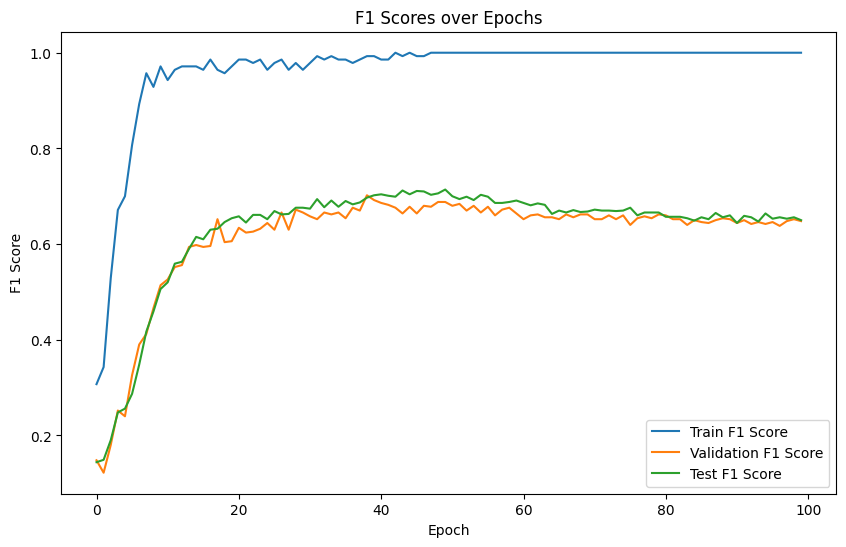

In [284]:
# Plot the F1 scores of last run
plt.figure(figsize=(10, 6))
plt.plot(train_f1_scores, label='Train F1 Score')
plt.plot(val_f1_scores, label='Validation F1 Score')
plt.plot(test_f1_scores, label='Test F1 Score')
# plt.plot(loss_scores, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('F1 Scores over Epochs')
plt.legend()
plt.show()

In [285]:
for batch in cluster_loader:
    print(batch.num_nodes)
    print(batch.edge_index.shape)

2708
torch.Size([2, 10556])


In [286]:
import networkx as nx
import matplotlib.pyplot as plt
import torch
import matplotlib.colors as mcolors
from torch_geometric.utils import to_networkx
from torch_geometric.data import Data

In [287]:
torch.where(data.train_mask == True)

(tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
          14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
          28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
          42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
          56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
          70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
          84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
          98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
         112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
         126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139],
        device='cuda:0'),)

In [288]:
def count_edges_with_different_labels(data, sampled_edge_index):
    """
    Counts edges with different labels at endpoints in both the original and sampled graphs.
    
    Args:
        data: Data object containing the original graph information.
        sampled_edge_index: Edge index of the sampled subgraph.
    
    Returns:
        A dictionary with counts and percentages of edges with different labels.
    """
    # Original graph edges
    original_edges = data.edge_index
    num_original_edges = original_edges.size(1)
    
    # Count edges with different labels in the original graph
    different_label_edges_original = 0
    for i in range(num_original_edges):
        node1, node2 = original_edges[:, i]
        if data.y[node1].item() != data.y[node2].item():
            different_label_edges_original += 1
    
    # Sampled graph edges
    sampled_edges = sampled_edge_index
    num_sampled_edges = sampled_edges.size(1)

    # Count edges with different labels in the sampled graph
    different_label_edges_sampled = 0
    for i in range(num_sampled_edges):
        node1, node2 = sampled_edges[:, i]
        if data.y[node1].item() != data.y[node2].item():
            different_label_edges_sampled += 1

    # Calculate percentages
    percentage_original = (different_label_edges_original / num_original_edges) * 100 if num_original_edges > 0 else 0
    percentage_sampled = (different_label_edges_sampled / num_sampled_edges) * 100 if num_sampled_edges > 0 else 0

    # Prepare the result
    result = {
        "original_graph": {
            "different_label_edges": different_label_edges_original,
            "total_edges": num_original_edges,
            "percentage": percentage_original
        },
        "sampled_graph": {
            "different_label_edges": different_label_edges_sampled,
            "total_edges": num_sampled_edges,
            "percentage": percentage_sampled
        }
    }

    return result

In [289]:
def plot_full_graph_with_train_nodes(data, train_mask, ax=None):
    """
    Plots the full graph with training nodes highlighted and colored by their labels.
    Args:
        data: Data object containing edge_index, node labels, and other features.
        train_mask: Boolean tensor indicating training nodes.
        ax: Matplotlib axis on which to plot (for side-by-side plotting).
    """
    # Convert PyG data to NetworkX graph for visualization
    G = to_networkx(data)
    
    # Generate color map for each label
    unique_labels = torch.unique(data.y[train_mask]).tolist()
    color_map = {label: color for label, color in zip(unique_labels, mcolors.TABLEAU_COLORS)}

    # Set node colors based on whether they are a training node and their label
    node_colors = [
        color_map[data.y[i].item()] if train_mask[i].item() else 'gray' for i in range(data.num_nodes)
    ]
    
    pos = None
    
    if DATASET_NAME == 'moon':
        pos = {i: (data.x[i][0].item(), data.x[i][1].item()) for i in range(len(data.x))}
    elif pos is None:
        pos = nx.spring_layout(G, seed=42)

    # Plot the full graph with training nodes highlighted by label color
    nx.draw(G, pos, node_color=node_colors, ax=ax, with_labels=False, node_size=100, edge_color="lightblue")
    
    # Add label above each node showing the label value
    for node, p in pos.items():
        label = data.y[node].item()
        ax.text(p[0], p[1] + 0.05, str(label), fontsize=8, ha='center', va='center')
    
    ax.set_title("Full Graph with Training Nodes Highlighted by Label")
    ax.axis("off")
    
    return pos


def plot_sampled_subgraph(data, sampled_edge_index, train_mask, ax=None, pos=None):
    """
    Plots the sampled subgraph based on the edge probability model with training nodes highlighted by label.
    Args:
        data: Data object containing node information.
        sampled_edge_index: Edge index of the sampled subgraph.
        train_mask: Boolean tensor indicating training nodes.
        ax: Matplotlib axis on which to plot (for side-by-side plotting).
    """
    # Convert sampled edges to NetworkX graph
    G_sampled = to_networkx(Data(x = data.x, y = data.y, edge_index = sampled_edge_index))
    
    # Use same color map as the full graph
    unique_labels = torch.unique(data.y[train_mask]).tolist()
    color_map = {label: color for label, color in zip(unique_labels, mcolors.TABLEAU_COLORS)}

    # Use same layout as the full graph for consistent positioning
    if pos is None:
        pos = nx.spring_layout(G_sampled, seed=42)
    
    # Set node colors based on training status and label for nodes in the sampled graph
    node_colors = [
        color_map[data.y[i].item()] if train_mask[i].item() and i in G_sampled.nodes else 'gray'
        for i in G_sampled.nodes
    ]

    # Plot the sampled subgraph with node labels
    nx.draw(G_sampled, pos, node_color=node_colors, ax=ax, with_labels=False, node_size=100, edge_color="orange")
    
    # Add label above each node showing the label value
    for node, p in pos.items():
        label = data.y[node].item()
        ax.text(p[0], p[1] + 0.05, str(label), fontsize=8, ha='center', va='center')
    
    ax.set_title("Sampled Subgraph (Edge Probability Model) with Training Nodes Highlighted by Label")
    ax.axis("off")


def visualize_graphs_side_by_side(data, train_mask, sampled_edge_index, show=True):
    """
    Visualizes the full graph with training nodes and the sampled subgraph side by side, with training nodes colored by label.
    Args:
        data: Data object containing the full graph information.
        train_mask: Boolean tensor indicating training nodes.
        sampled_edge_index: Edge index of the sampled subgraph.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    
    # Plot full graph with training nodes highlighted by label
    pos1 = plot_full_graph_with_train_nodes(data, train_mask, ax=ax1)

    # Plot sampled subgraph with training nodes highlighted by label, using the same layout
    plot_sampled_subgraph(data, sampled_edge_index, train_mask, ax=ax2, pos=pos1)
    
    if show==False:
        plt.close()
    else:
        plt.show()
    
    return fig

# Example Usage:
# Assuming `train_mask` is a boolean mask tensor, and `sampled_edge_index` is the edge index after sampling
# visualize_graphs_side_by_side(data, train_mask=data.train_mask, sampled_edge_index=sampled_edge_index)

In [290]:
def visualize(istest=True, show=True):
    if use_metis == False:
        with torch.no_grad():
            edge_probs = model.edge_prob_mlp(data.x, data.edge_index).squeeze()
            sampled_edge_indices, sampled_edge_weight = gumbel_softmax_sampling(data,
                edge_probs,
                data.edge_index,
                q=sample_size, istest=istest)

            sampled_edge_index = data.edge_index[:, sampled_edge_indices]
            fig = None
            #fig = visualize_graphs_side_by_side(data, train_mask=data.train_mask, sampled_edge_index=sampled_edge_index, show=show)

            # Example Usage
            # Assuming `data` is your original graph and `sampled_edge_index` is your sampled edge index
            result = count_edges_with_different_labels(data, sampled_edge_index)

            print("\% of heterophily:")

            # Print the results
            print(f"Original graph: {result['original_graph']['different_label_edges']} edges with different labels "
                  f"out of {result['original_graph']['total_edges']} total edges "
                  f"({result['original_graph']['percentage']:.2f}%).")

            print(f"Sampled graph: {result['sampled_graph']['different_label_edges']} edges with different labels "
                  f"out of {result['sampled_graph']['total_edges']} total edges "
                  f"({result['sampled_graph']['percentage']:.2f}%).")
            
            return fig
            
fig = visualize(False) #Sampled from the best
fig = visualize(True)  #Best Sparsifier

\% of heterophily:
Original graph: 2006 edges with different labels out of 10556 total edges (19.00%).
Sampled graph: 377 edges with different labels out of 2111 total edges (17.86%).
\% of heterophily:
Original graph: 2006 edges with different labels out of 10556 total edges (19.00%).
Sampled graph: 367 edges with different labels out of 2111 total edges (17.39%).


In [291]:
# def sample_gumbel(shape, eps=1e-20):
#     """Sample from Gumbel(0, 1)"""
#     U = torch.rand(shape)
#     return -torch.log(-torch.log(U + eps) + eps)

# # Example usage
# shape = (10,)  # Sample 10 values
# gumbel_noise = sample_gumbel(shape)
# print(gumbel_noise)

## Animate the Sparsification

In [292]:
def store_figures_during_test():
    figures = []
    for epoch in range(20):  # Assuming 100 epochs
        fig = visualize(False, False)
        figures.append(fig)
        plt.close(fig)
    return figures

# figures = store_figures_during_test()

In [293]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def create_animation_from_figures(figures):
    fig_anim, ax_anim = plt.subplots()

    def update_fig(i):
        ax_anim.clear()
        figures[i].canvas.draw()
        img_array = np.frombuffer(figures[i].canvas.tostring_rgb(), dtype=np.uint8)
        img_array = img_array.reshape(figures[i].canvas.get_width_height()[::-1] + (3,))
        ax_anim.imshow(img_array)
        ax_anim.axis('off')

    ani = animation.FuncAnimation(fig_anim, update_fig, frames=len(figures), interval=200, blit=False)

    from IPython.display import HTML
    return HTML(ani.to_jshtml())

# # Example Usage:
# # Assuming `figures` is a list of stored figure objects from `store_figures_during_training`.
# animation_html = create_animation_from_figures(figures)
# display(animation_html)

In [294]:
if figure_log:
    animation_html = create_animation_from_figures(train_figures)
    display(animation_html)